# Carbon Stock Estimation — Ludhiana District

Estimating above-ground and below-ground carbon stock across a 250 m grid
covering Ludhiana district, Punjab, using Random Forest and XGBoost on
remote-sensing and soil predictors.

**How to run:** execute the cells top to bottom. Steps 1-8 are the analysis
pipeline. Steps 9-10 load results into local databases. Steps 11-12 are
optional cloud sync.

**Before you start:** a `.env` file must exist in the project root with
`PROJECT_ROOT` and `PG_PASSWORD` set. No passwords appear in this notebook.

## Step 1 — Configuration

Every path and constant used by the notebook lives here. Nothing else in the
notebook hardcodes a folder. If the project moves, only `.env` changes.

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

# .env sits in the project root, two levels above this notebook (IIRS/Scrpt/)
NOTEBOOK_DIR = Path.cwd()
ROOT = Path(os.getenv("PROJECT_ROOT", NOTEBOOK_DIR.parents[1]))
load_dotenv(ROOT / ".env")
ROOT = Path(os.getenv("PROJECT_ROOT", ROOT))          # re-read after loading

DATA = ROOT / "IIRS" / "Carbon_Stocks"

# ── Column names ──────────────────────────────────────────────────────
NPP_COL   = "Agricultur"          # above-ground target
SOC_COL   = "SOC_mean"            # below-ground target
NDVI_COLS = ["NDVI_Jun24", "NDVI_Jul24", "NDVI_Aug24", "NDVI_Sep24",
             "NDVI_Oct24", "NDVI_Nov24", "NDVI_Dec24", "NDVI_Jan25",
             "NDVI_Feb25", "NDVI_Mar25", "NDVI_Apr25", "NDVI_May25"]

AG_FEATURES = [
    "DEM_mean",   "Slope_mean", "Kharif_pea",  "Kharif_Pre",
    "LST_Sept20", "Rabi_LST_2", "Rabi_Peak_",  "Rabi_Preci",
    "Kharif_Lud", "NDWI_Rabi_",
] + NDVI_COLS
BG_FEATURES = ["agri_class", "DEM_mean", "Slope_mean",
               "sand_pct", "clay_pct", "bd_gcm3"]

# ── Study-area constants ──────────────────────────────────────────────
CELL_AREA_HA  = 6.25              # 250 m x 250 m
TOTAL_CELLS   = 66790             # cells in the original grid export
AGRI_CELLS    = 50402             # cells classified agricultural
GENUINE_CELLS = round(AGRI_CELLS * 12602 / 16252)   # 39,082 (see Step 4)
NPP_TO_AGC    = 0.47              # carbon fraction of NPP
SOC_DEPTH_CM  = 30                # soil sampling depth
CO2_FACTOR    = 44 / 12           # C -> CO2 equivalent
RANDOM_STATE  = 42

print("Project root:", ROOT)
print("Data folder :", DATA)
if not DATA.is_dir():
    raise FileNotFoundError(
        f"Data folder not found: {DATA}\n"
        f"Fix PROJECT_ROOT in {ROOT / '.env'}"
    )
print("Config loaded.")

Project root: C:\Projects\My Projects\BDA PROJECT
Data folder : C:\Projects\My Projects\BDA PROJECT\IIRS\Carbon_Stocks
Config loaded.


## Step 2 — Check input files

Confirms the six raw inputs are present before anything else runs.

In [2]:
REQUIRED_FILES = [
    "Above_ground_data_geom.csv",
    "Below_Ground_Data_geom.csv",
    "ndvi_monthly_ludhiana_jun24_may25.csv",
    "AGD_for_all_grids_geom.csv",
    "BGD_for_all_grids(GEOM).csv",
    "ndvi_monthly_ludhiana_all_66790.csv",
]

missing = [f for f in REQUIRED_FILES if not (DATA / f).exists()]
if missing:
    print("WARNING — these files are missing:", missing)
else:
    print("All required files found.")

print("\nFolder contents:")
for name in sorted(p.name for p in DATA.iterdir()):
    print("   ", name)

All required files found.

Folder contents:
    AGD_for_all_grids_geom.csv
    Above_ground_data_geom.csv
    BGD_for_all_grids(GEOM).csv
    Below_Ground_Data_geom.csv
    above_ground_clean.csv
    ag_X_test.csv
    ag_X_train.csv
    ag_carbon_per_cell.csv
    ag_y_test.csv
    ag_y_train.csv
    ag_zero_npp_cells.csv
    below_ground_clean.csv
    bg_X_test.csv
    bg_X_train.csv
    bg_carbon_per_cell.csv
    bg_y_test.csv
    bg_y_train.csv
    carbon_all_66790_final.csv
    carbon_final_report.txt
    carbon_project
    district_carbon_summary_66790.txt
    evaluation_report.txt
    model_ag_rf.pkl
    model_ag_xgb.pkl
    model_bg_rf.pkl
    model_bg_xgb.pkl
    ndvi_monthly_ludhiana_all_66790.csv
    ndvi_monthly_ludhiana_jun24_may25.csv
    plot1_actual_vs_predicted.png
    plot2_residuals.png
    plot3_feature_importance.png
    plot4_error_distribution.png
    plot5_carbon_distribution.png
    plot6_carbon_summary.png


## Step 3 — Data cleaning and NDVI merge

Reads the 20,000-cell training extracts, attaches monthly NDVI to the
above-ground table, fills gaps with column medians, and writes two clean
files for the next step.

In [3]:
import pandas as pd
import numpy as np

ag   = pd.read_csv(DATA / "Above_ground_data_geom.csv")
bg   = pd.read_csv(DATA / "Below_Ground_Data_geom.csv")
ndvi = pd.read_csv(DATA / "ndvi_monthly_ludhiana_jun24_may25.csv")
print(f"AG: {ag.shape}   BG: {bg.shape}   NDVI: {ndvi.shape}")

# NDVI: drop coordinates, average duplicate rows per grid cell
ndvi = ndvi.drop(columns=["longitude", "latitude"], errors="ignore")
ndvi = ndvi.groupby("Grid_ID")[NDVI_COLS].mean().reset_index()

# Attach NDVI to the above-ground table
ag = ag.merge(ndvi, on="Grid_ID", how="left")
for col in NDVI_COLS:
    ag[col] = ag[col].fillna(ag[col].median())

# Geometry and IDs are not model features
ag = ag.drop(columns=["WKT", "Grid_ID"])
bg = bg.drop(columns=["WKT", "Grid_ID"])

# NPP cannot be negative; missing means zero production
ag[NPP_COL] = ag[NPP_COL].fillna(0).clip(lower=0)

# Median-fill every remaining predictor
for col in [c for c in ag.columns if c != NPP_COL]:
    ag[col] = ag[col].fillna(ag[col].median())
for col in [c for c in bg.columns if c != SOC_COL]:
    bg[col] = bg[col].fillna(bg[col].median())

# Target last, for readability
ag = ag[[c for c in ag.columns if c != NPP_COL] + [NPP_COL]]

ag.to_csv(DATA / "above_ground_clean.csv", index=False)
bg.to_csv(DATA / "below_ground_clean.csv", index=False)
print(f"above_ground_clean.csv saved: {ag.shape}")
print(f"below_ground_clean.csv saved: {bg.shape}")
print("STEP 3 COMPLETE")

AG: (20000, 14)   BG: (20000, 9)   NDVI: (20000, 15)
above_ground_clean.csv saved: (20000, 24)
below_ground_clean.csv saved: (20000, 7)
STEP 3 COMPLETE


## Step 4 — Train / test split

Above-ground modelling uses only agricultural cells with non-zero NPP.
Cells with zero NPP are set aside rather than deleted — the ratio of genuine
to total agricultural cells (12,602 / 16,252) is what scales the district
estimate later.

*Known limitation:* the split is random, so neighbouring 250 m cells can land
in both train and test. Spatially adjacent cells are highly correlated, which
inflates test scores. Spatial block cross-validation would be the rigorous
alternative.

In [4]:
from sklearn.model_selection import train_test_split

ag = pd.read_csv(DATA / "above_ground_clean.csv")
bg = pd.read_csv(DATA / "below_ground_clean.csv")
print(f"AG: {ag.shape}   BG: {bg.shape}")

ag_agri    = ag[ag["agri_class"] == 1].copy()
ag_nonzero = ag_agri[ag_agri[NPP_COL] > 0].copy()
ag_zero    = ag_agri[ag_agri[NPP_COL] == 0].copy()
print(f"Genuine NPP cells: {len(ag_nonzero)}   Zero-NPP cells: {len(ag_zero)}")

ag_feature_cols = [c for c in ag_nonzero.columns
                   if c not in ["agri_class", NPP_COL]]
X_ag_train, X_ag_test, y_ag_train, y_ag_test = train_test_split(
    ag_nonzero[ag_feature_cols], ag_nonzero[NPP_COL],
    test_size=0.2, random_state=RANDOM_STATE)
print(f"AG Train: {X_ag_train.shape}   Test: {X_ag_test.shape}")

bg_feature_cols = [c for c in bg.columns if c != SOC_COL]
X_bg_train, X_bg_test, y_bg_train, y_bg_test = train_test_split(
    bg[bg_feature_cols], bg[SOC_COL],
    train_size=16000, test_size=4000, random_state=RANDOM_STATE)
print(f"BG Train: {X_bg_train.shape}   Test: {X_bg_test.shape}")

for obj, name in [
    (X_ag_train, "ag_X_train.csv"), (X_ag_test, "ag_X_test.csv"),
    (y_ag_train, "ag_y_train.csv"), (y_ag_test, "ag_y_test.csv"),
    (X_bg_train, "bg_X_train.csv"), (X_bg_test, "bg_X_test.csv"),
    (y_bg_train, "bg_y_train.csv"), (y_bg_test, "bg_y_test.csv"),
    (ag_zero,    "ag_zero_npp_cells.csv"),
]:
    obj.to_csv(DATA / name, index=False, header=True)

print("All split files saved. STEP 4 COMPLETE")

AG: (20000, 24)   BG: (20000, 7)
Genuine NPP cells: 12602   Zero-NPP cells: 3650
AG Train: (10081, 22)   Test: (2521, 22)
BG Train: (16000, 6)   Test: (4000, 6)
All split files saved. STEP 4 COMPLETE


## Step 5 — Train models

Random Forest and gradient boosting for each carbon pool. Four models total,
saved as pickles so later steps do not need to retrain.

In [5]:
import pickle, time
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

try:
    from xgboost import XGBRegressor
    USE_XGB, XGB_LABEL = True, "XGBoost"
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    USE_XGB, XGB_LABEL = False, "GradientBoosting"
    print("XGBoost not installed — using GradientBoosting instead")

X_ag_train = pd.read_csv(DATA / "ag_X_train.csv")
y_ag_train = pd.read_csv(DATA / "ag_y_train.csv").squeeze()
X_bg_train = pd.read_csv(DATA / "bg_X_train.csv")
y_bg_train = pd.read_csv(DATA / "bg_y_train.csv").squeeze()
print(f"AG train: {X_ag_train.shape}   BG train: {X_bg_train.shape}")

RF_PARAMS = dict(n_estimators=300, min_samples_split=4, min_samples_leaf=2,
                 n_jobs=-1, random_state=RANDOM_STATE)
if USE_XGB:
    XGB_PARAMS = dict(n_estimators=300, learning_rate=0.05, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8,
                      n_jobs=-1, random_state=RANDOM_STATE, verbosity=0)
else:
    XGB_PARAMS = dict(n_estimators=200, learning_rate=0.05, max_depth=5,
                      subsample=0.8, random_state=RANDOM_STATE)

def boost():
    return XGBRegressor(**XGB_PARAMS) if USE_XGB else GradientBoostingRegressor(**XGB_PARAMS)

def train(label, model, X, y):
    print(f"Training {label} ...", end="", flush=True)
    t = time.time()
    model.fit(X, y)
    r2 = r2_score(y, np.maximum(model.predict(X), 0))
    print(f"  {time.time() - t:.1f}s   train R2={r2:.4f}")
    return model

rf_ag  = train("RF  AG",          RandomForestRegressor(**RF_PARAMS), X_ag_train, y_ag_train)
xgb_ag = train(f"{XGB_LABEL} AG", boost(),                            X_ag_train, y_ag_train)
rf_bg  = train("RF  BG",          RandomForestRegressor(**RF_PARAMS), X_bg_train, y_bg_train)
xgb_bg = train(f"{XGB_LABEL} BG", boost(),                            X_bg_train, y_bg_train)

for model, name in [(rf_ag,  "model_ag_rf.pkl"), (xgb_ag, "model_ag_xgb.pkl"),
                    (rf_bg,  "model_bg_rf.pkl"), (xgb_bg, "model_bg_xgb.pkl")]:
    with open(DATA / name, "wb") as f:
        pickle.dump(model, f)

print("All 4 models saved. STEP 5 COMPLETE")

AG train: (10081, 22)   BG train: (16000, 6)
Training RF  AG ...  4.0s   train R2=0.9088
Training XGBoost AG ...  0.4s   train R2=0.8197
Training RF  BG ...  1.1s   train R2=0.9928
Training XGBoost BG ...  0.2s   train R2=0.9756
All 4 models saved. STEP 5 COMPLETE


## Step 6 — Evaluate models

Test-set R², RMSE and MAE for both pools, plus four diagnostic figures.

*Two results worth interpreting rather than just reporting:*

- **Above-ground:** train R² ≈ 0.91 against test R² ≈ 0.54 is a large gap.
  The forest is memorising training cells. Constraining depth or raising
  `min_samples_leaf` would trade fit for generalisation.
- **Below-ground:** R² ≈ 0.97 is suspiciously high. SOC is predicted from
  sand, clay and bulk density — all derived from the same gridded soil
  product as the target. The predictors and the target are not independent
  measurements, so this score overstates real predictive skill.

In [6]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
%matplotlib inline

X_ag_test = pd.read_csv(DATA / "ag_X_test.csv")
y_ag_test = pd.read_csv(DATA / "ag_y_test.csv").squeeze()
X_bg_test = pd.read_csv(DATA / "bg_X_test.csv")
y_bg_test = pd.read_csv(DATA / "bg_y_test.csv").squeeze()

with open(DATA / "model_ag_rf.pkl",  "rb") as f: rf_ag  = pickle.load(f)
with open(DATA / "model_ag_xgb.pkl", "rb") as f: xgb_ag = pickle.load(f)
with open(DATA / "model_bg_rf.pkl",  "rb") as f: rf_bg  = pickle.load(f)
with open(DATA / "model_bg_xgb.pkl", "rb") as f: xgb_bg = pickle.load(f)

pred_rf_ag  = np.maximum(rf_ag.predict(X_ag_test),  0)
pred_xgb_ag = np.maximum(xgb_ag.predict(X_ag_test), 0)
pred_rf_bg  = np.maximum(rf_bg.predict(X_bg_test),  0)
pred_xgb_bg = np.maximum(xgb_bg.predict(X_bg_test), 0)

print(f"{'Model':<24} Target   R2       RMSE       MAE")
print("-" * 60)
results = []
for label, y_true, y_pred, target in [
    ("Random Forest",     y_ag_test, pred_rf_ag,  "NPP"),
    ("XGBoost/GradBoost", y_ag_test, pred_xgb_ag, "NPP"),
    ("Random Forest",     y_bg_test, pred_rf_bg,  "SOC"),
    ("XGBoost/GradBoost", y_bg_test, pred_xgb_bg, "SOC"),
]:
    r2   = r2_score(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    results.append({"label": label, "target": target, "R2": r2, "RMSE": rmse, "MAE": mae})
    print(f"{label:<24} {target:<6}  {r2:.4f}   {rmse:>8.3f}   {mae:>8.3f}")

best_ag = max((r for r in results if r["target"] == "NPP"), key=lambda x: x["R2"])
best_bg = max((r for r in results if r["target"] == "SOC"), key=lambda x: x["R2"])
pred_ag_best = pred_rf_ag if best_ag["label"] == "Random Forest" else pred_xgb_ag
pred_bg_best = pred_rf_bg if best_bg["label"] == "Random Forest" else pred_xgb_bg
best_ag_mdl  = rf_ag      if best_ag["label"] == "Random Forest" else xgb_ag
best_bg_mdl  = rf_bg      if best_bg["label"] == "Random Forest" else xgb_bg
print(f"Best AG: {best_ag['label']}  R2={best_ag['R2']:.4f}")
print(f"Best BG: {best_bg['label']}  R2={best_bg['R2']:.4f}")

Model                    Target   R2       RMSE       MAE
------------------------------------------------------------
Random Forest            NPP     0.5426    448.598    314.789
XGBoost/GradBoost        NPP     0.5330    453.274    319.171
Random Forest            SOC     0.9665      1.392      1.012
XGBoost/GradBoost        SOC     0.9650      1.423      1.053
Best AG: Random Forest  R2=0.5426
Best BG: Random Forest  R2=0.9665


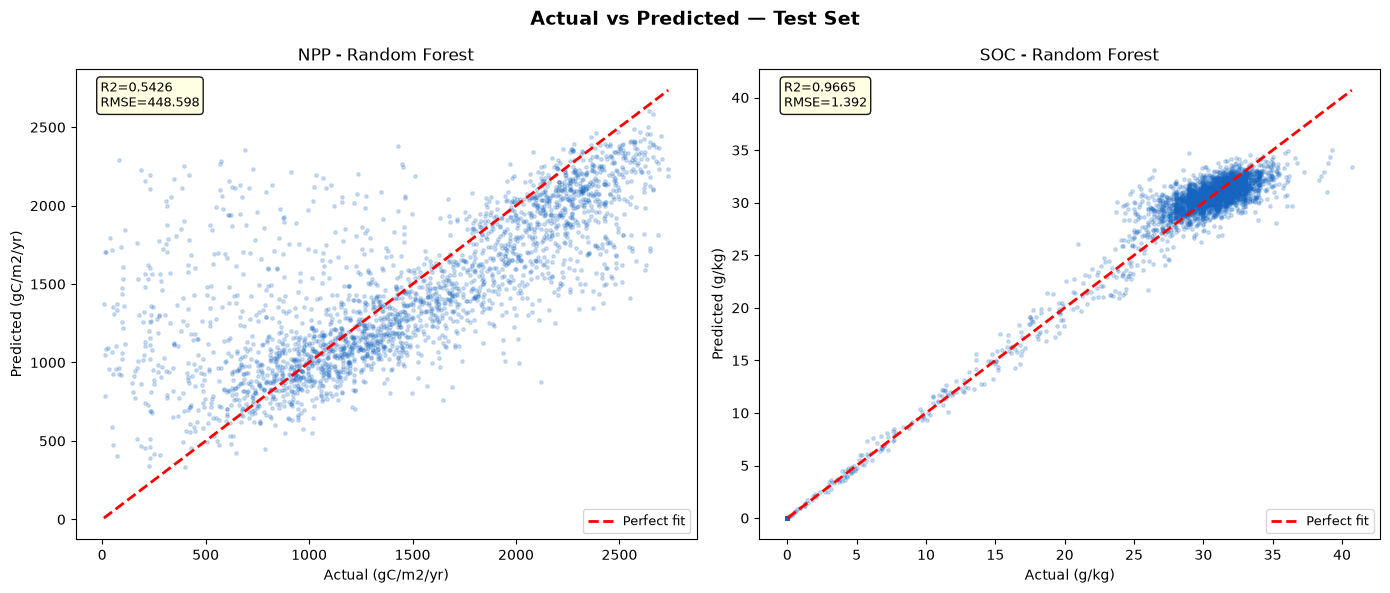

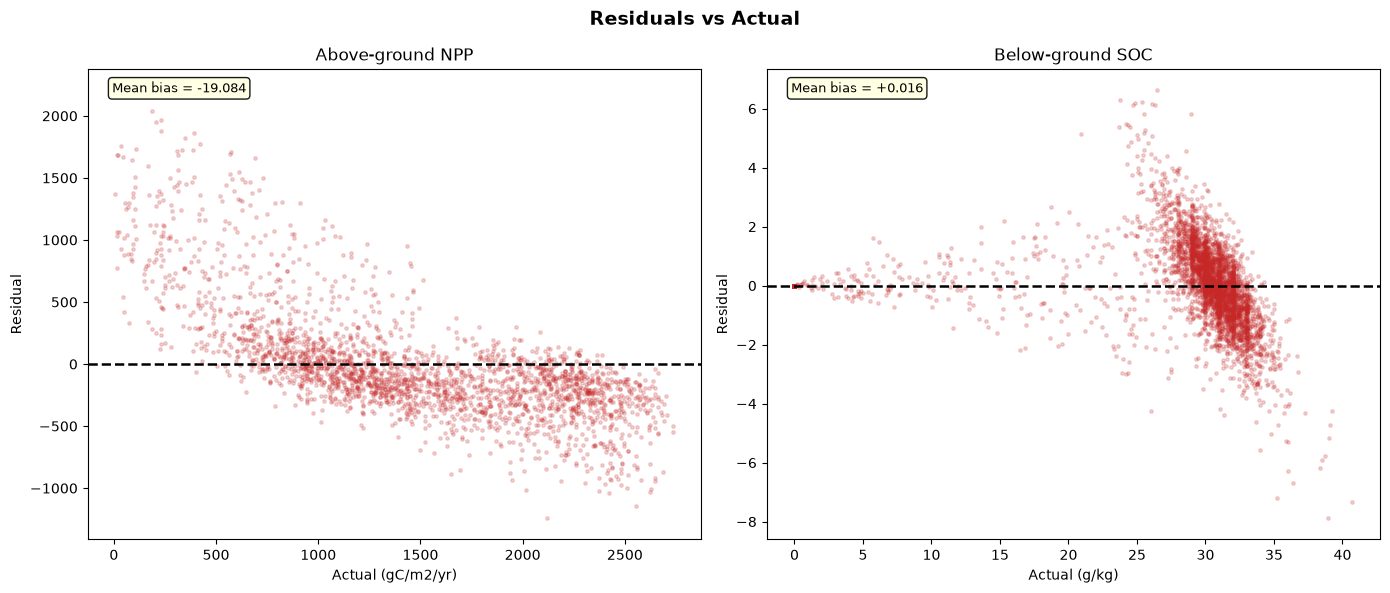

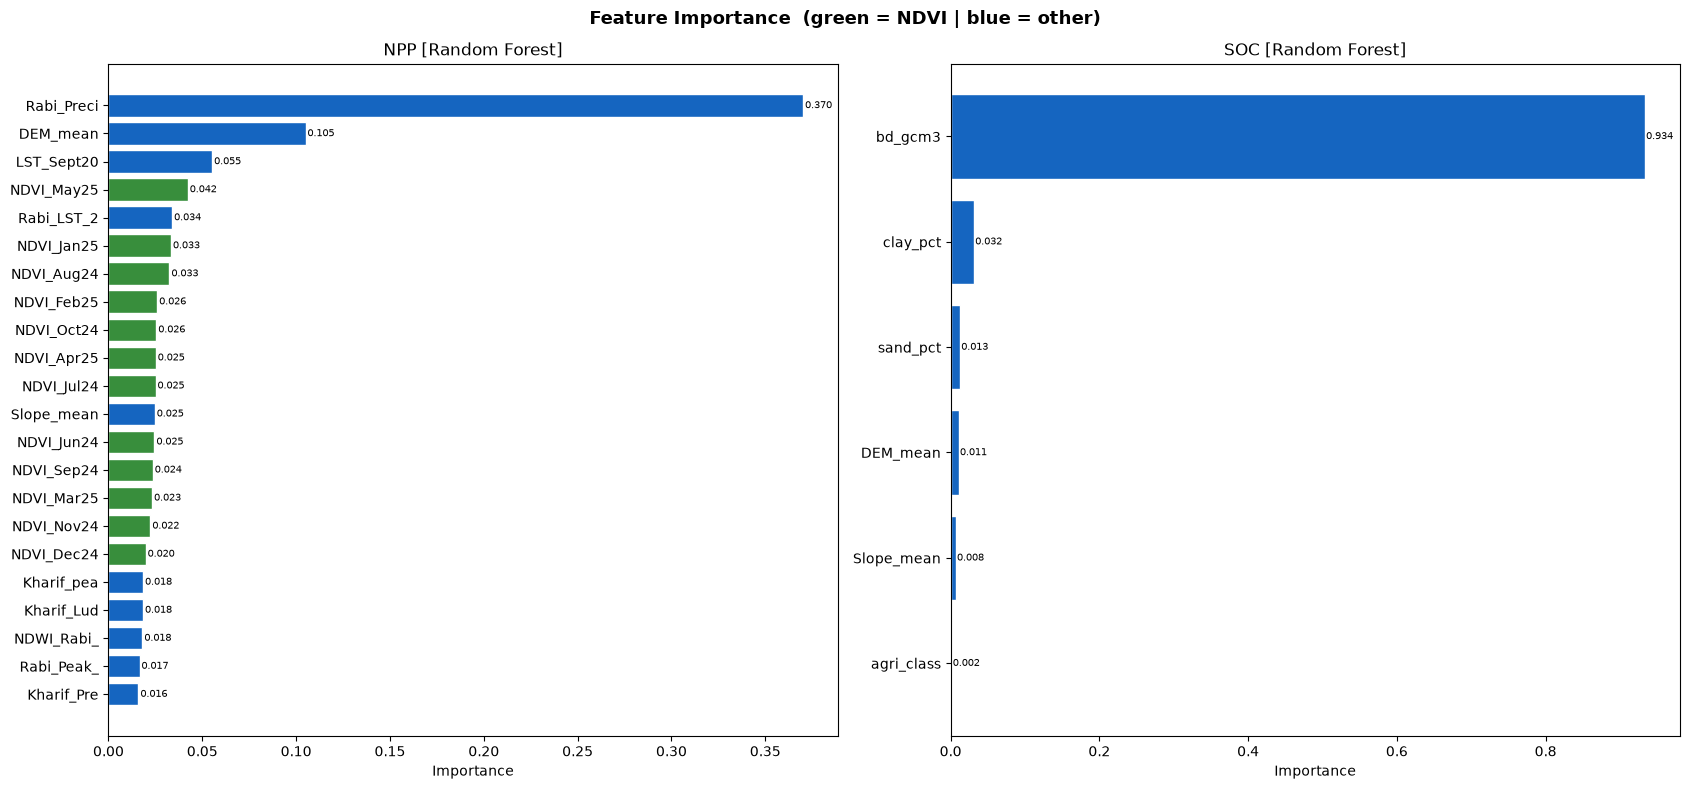

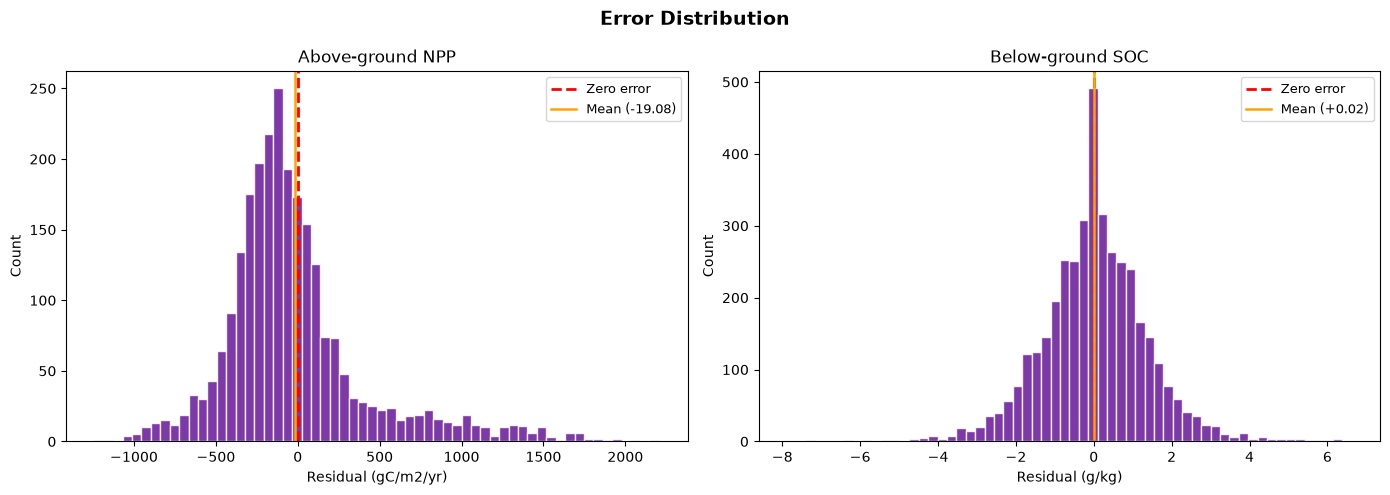

4 figures and evaluation_report.txt saved. STEP 6 COMPLETE


In [7]:
# Figure 1 — Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Actual vs Predicted — Test Set", fontsize=14, fontweight="bold")
for ax, y_true, y_pred, m, unit in [
    (axes[0], y_ag_test, pred_ag_best, best_ag, "gC/m2/yr"),
    (axes[1], y_bg_test, pred_bg_best, best_bg, "g/kg"),
]:
    ax.scatter(y_true, y_pred, alpha=0.2, s=6, color="#1565C0", rasterized=True)
    lo = min(float(y_true.min()), float(y_pred.min()))
    hi = max(float(y_true.max()), float(y_pred.max()))
    ax.plot([lo, hi], [lo, hi], "r--", lw=2, label="Perfect fit")
    ax.set_xlabel(f"Actual ({unit})"); ax.set_ylabel(f"Predicted ({unit})")
    ax.set_title(f"{m['target']} - {m['label']}"); ax.legend(fontsize=9)
    ax.text(0.04, 0.92, f"R2={m['R2']:.4f}\nRMSE={m['RMSE']:.3f}",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))
plt.tight_layout()
plt.savefig(DATA / "plot1_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# Figure 2 — Residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Residuals vs Actual", fontsize=14, fontweight="bold")
for ax, y_true, y_pred, title, unit in [
    (axes[0], y_ag_test, pred_ag_best, "Above-ground NPP", "gC/m2/yr"),
    (axes[1], y_bg_test, pred_bg_best, "Below-ground SOC", "g/kg"),
]:
    res = y_pred - y_true
    ax.scatter(y_true, res, alpha=0.2, s=6, color="#C62828", rasterized=True)
    ax.axhline(0, color="black", lw=1.8, linestyle="--")
    ax.set_xlabel(f"Actual ({unit})"); ax.set_ylabel("Residual"); ax.set_title(title)
    ax.text(0.04, 0.95, f"Mean bias = {float(res.mean()):+.3f}",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9))
plt.tight_layout()
plt.savefig(DATA / "plot2_residuals.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# Figure 3 — Feature importance
fig, axes = plt.subplots(1, 2, figsize=(17, 8))
fig.suptitle("Feature Importance  (green = NDVI | blue = other)",
             fontsize=13, fontweight="bold")
for ax, model, feat_names, title in [
    (axes[0], best_ag_mdl, list(X_ag_test.columns), f"NPP [{best_ag['label']}]"),
    (axes[1], best_bg_mdl, list(X_bg_test.columns), f"SOC [{best_bg['label']}]"),
]:
    imp = model.feature_importances_
    idx = np.argsort(imp)
    colors = ["#388E3C" if feat_names[i] in NDVI_COLS else "#1565C0" for i in idx]
    ax.barh(np.array(feat_names)[idx], imp[idx], color=colors, edgecolor="white")
    ax.set_xlabel("Importance"); ax.set_title(title)
    for i, v in enumerate(imp[idx]):
        ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=7.5)
plt.tight_layout()
plt.savefig(DATA / "plot3_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# Figure 4 — Error distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Error Distribution", fontsize=14, fontweight="bold")
for ax, y_true, y_pred, title, unit in [
    (axes[0], y_ag_test, pred_ag_best, "Above-ground NPP", "gC/m2/yr"),
    (axes[1], y_bg_test, pred_bg_best, "Below-ground SOC", "g/kg"),
]:
    res = y_pred - y_true
    ax.hist(res, bins=60, color="#6A1B9A", edgecolor="white", alpha=0.87)
    ax.axvline(0, color="red", lw=2, linestyle="--", label="Zero error")
    ax.axvline(float(res.mean()), color="orange", lw=1.8,
               label=f"Mean ({float(res.mean()):+.2f})")
    ax.set_xlabel(f"Residual ({unit})"); ax.set_ylabel("Count"); ax.set_title(title)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(DATA / "plot4_error_distribution.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

report = "EVALUATION REPORT\n" + "=" * 40 + "\n"
for r in results:
    report += (f"{r['label']} {r['target']}  R2={r['R2']:.4f}  "
               f"RMSE={r['RMSE']:.3f}  MAE={r['MAE']:.3f}\n")
(DATA / "evaluation_report.txt").write_text(report, encoding="utf-8")
print("4 figures and evaluation_report.txt saved. STEP 6 COMPLETE")

## Step 7 — Carbon on the test set (validation estimate)

Applies the carbon conversion formulas to the 2,521 above-ground and 4,000
below-ground test cells, then scales to district level.

```
AGC (tC/ha) = NPP (gC/m2/yr) x 0.47 / 100
BGC (tC/ha) = SOC (g/kg) x bulk density (g/cm3) x 30 cm / 10
```

**Read this number as a validation check, not the headline result.** It
extrapolates from a few thousand test cells. Step 8 predicts every cell
individually and is the figure to quote in the report.

**On terminology:** NPP is annual carbon *production*, not standing biomass.
Calling the above-ground figure a carbon "stock" alongside a 30 cm soil stock
compares a yearly flux with an accumulated pool, which is why above-ground
looks so small. Describe it as annual above-ground carbon accumulation, or be
ready to justify the comparison.

In [8]:
X_ag_test = pd.read_csv(DATA / "ag_X_test.csv")
y_ag_test = pd.read_csv(DATA / "ag_y_test.csv").squeeze()
X_bg_test = pd.read_csv(DATA / "bg_X_test.csv")
y_bg_test = pd.read_csv(DATA / "bg_y_test.csv").squeeze()
with open(DATA / "model_ag_rf.pkl", "rb") as f: model_ag = pickle.load(f)
with open(DATA / "model_bg_rf.pkl", "rb") as f: model_bg = pickle.load(f)

pred_npp     = np.maximum(model_ag.predict(X_ag_test), 0)
pred_soc     = np.maximum(model_bg.predict(X_bg_test), 0)
agc_per_cell = pred_npp * NPP_TO_AGC / 100.0
bd_values    = X_bg_test["bd_gcm3"].values
bgc_per_cell = pred_soc * bd_values * SOC_DEPTH_CM / 10.0

district_agc   = agc_per_cell.mean() * GENUINE_CELLS * CELL_AREA_HA
district_bgc   = bgc_per_cell.mean() * TOTAL_CELLS   * CELL_AREA_HA
district_total = district_agc + district_bgc
agc_MtC, bgc_MtC = district_agc / 1e6, district_bgc / 1e6
tot_MtC = district_total / 1e6
agc_pct = district_agc / district_total * 100
bgc_pct = district_bgc / district_total * 100

print("=" * 50)
print(f"Above-ground Carbon : {agc_MtC:.4f} million tC  ({agc_pct:.1f}%)")
print(f"Below-ground Carbon : {bgc_MtC:.4f} million tC  ({bgc_pct:.1f}%)")
print(f"TOTAL (test-set estimate) : {tot_MtC:.4f} million tC")
print("=" * 50)

pd.DataFrame({"Predicted_NPP": np.round(pred_npp, 4),
              "AGC_tC_ha":     np.round(agc_per_cell, 4),
              "True_NPP":      np.round(y_ag_test.values, 4)}
             ).to_csv(DATA / "ag_carbon_per_cell.csv", index=False)
pd.DataFrame({"Predicted_SOC": np.round(pred_soc, 4),
              "BD":            np.round(bd_values, 4),
              "BGC_tC_ha":     np.round(bgc_per_cell, 4),
              "True_SOC":      np.round(y_bg_test.values, 4)}
             ).to_csv(DATA / "bg_carbon_per_cell.csv", index=False)
print("Per-cell carbon files saved.")

Above-ground Carbon : 1.6678 million tC  (3.1%)
Below-ground Carbon : 52.5602 million tC  (96.9%)
TOTAL (test-set estimate) : 54.2280 million tC
Per-cell carbon files saved.


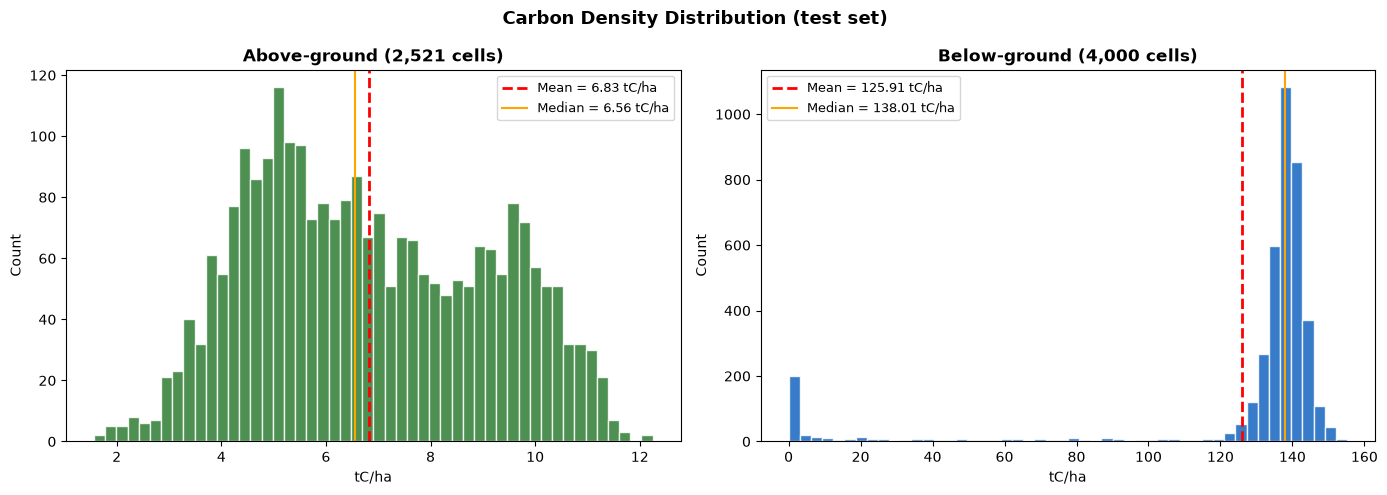

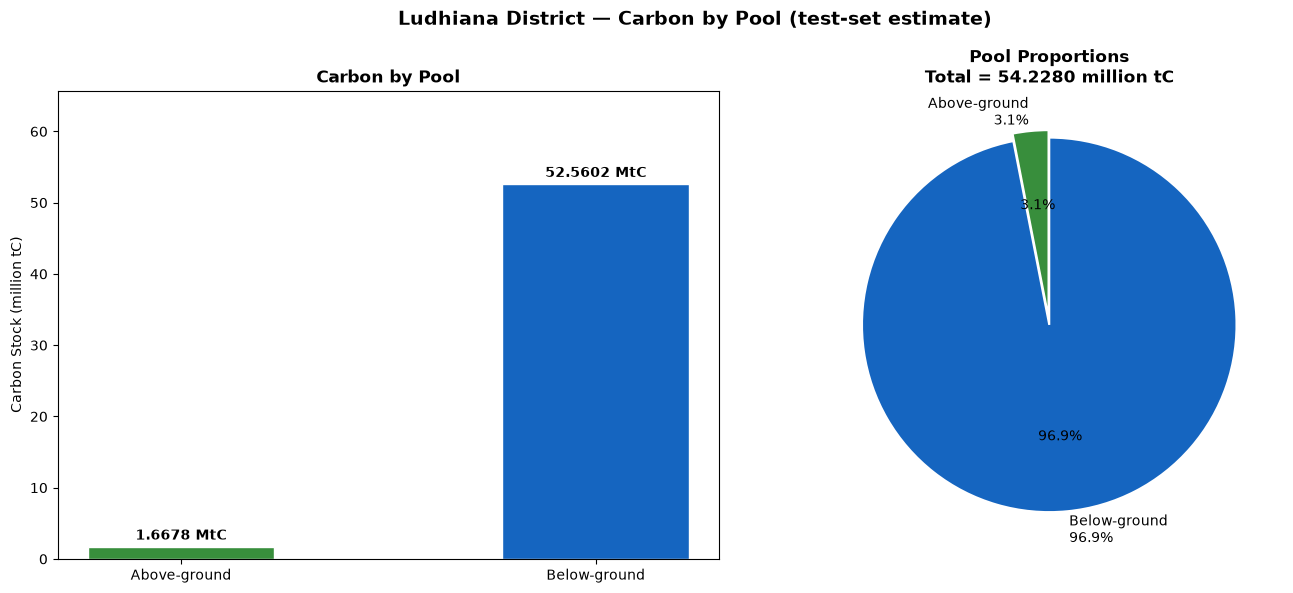

LUDHIANA DISTRICT - CARBON STOCK (TEST-SET ESTIMATE)

STUDY AREA
  District           : Ludhiana, Punjab, India
  Grid cell size     : 250m x 250m  =  6.25 ha per cell
  Total grid cells   : 66,790
  Agricultural cells : 50,402
  Grid-based area    : 417,438 ha
  Official area      : 376,700 ha  (3,767 km2)

CARBON FORMULAS
  Above-ground (tC/ha) = NPP (gC/m2/yr) x 0.47 / 100
  Below-ground (tC/ha) = SOC (g/kg) x BD x 30 cm / 10

SCALING
  Above-ground : mean density x 39,082 genuine NPP cells x 6.25 ha
  Below-ground : mean density x 66,790 total cells x 6.25 ha

CARBON DENSITY
  Above-ground mean : 6.8279 tC/ha
  Below-ground mean : 125.9115 tC/ha

DISTRICT CARBON STOCK (extrapolated from test set)
  -----------------------------------------------------------------
  Above-ground  :        1,667,802.32 tC  =  1.6678 MtC  (3.08%)
  Below-ground  :       52,560,180.48 tC  =  52.5602 MtC  (96.92%)
  -----------------------------------------------------------------
  TOTAL         :     

In [9]:
# Figure 5 — Carbon density distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Carbon Density Distribution (test set)", fontsize=13, fontweight="bold")
for ax, data, title, color in [
    (axes[0], agc_per_cell, f"Above-ground ({len(agc_per_cell):,} cells)", "#2E7D32"),
    (axes[1], bgc_per_cell, f"Below-ground ({len(bgc_per_cell):,} cells)", "#1565C0"),
]:
    ax.hist(data, bins=50, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(data.mean(), color="red", lw=2, linestyle="--",
               label=f"Mean = {data.mean():.2f} tC/ha")
    ax.axvline(float(np.median(data)), color="orange", lw=1.5,
               label=f"Median = {float(np.median(data)):.2f} tC/ha")
    ax.set_xlabel("tC/ha"); ax.set_ylabel("Count")
    ax.set_title(title, fontweight="bold"); ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(DATA / "plot5_carbon_distribution.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

# Figure 6 — District summary
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Ludhiana District — Carbon by Pool (test-set estimate)",
             fontsize=14, fontweight="bold")
bars = axes[0].bar(["Above-ground", "Below-ground"], [agc_MtC, bgc_MtC],
                   color=["#388E3C", "#1565C0"], edgecolor="white", width=0.45)
axes[0].set_ylabel("Carbon Stock (million tC)")
axes[0].set_title("Carbon by Pool", fontweight="bold")
axes[0].set_ylim(0, max(agc_MtC, bgc_MtC) * 1.25)
for bar, val in zip(bars, [agc_MtC, bgc_MtC]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + max(agc_MtC, bgc_MtC) * 0.02,
                 f"{val:.4f} MtC", ha="center", fontsize=10, fontweight="bold")
axes[1].pie([district_agc, district_bgc],
            labels=[f"Above-ground\n{agc_pct:.1f}%", f"Below-ground\n{bgc_pct:.1f}%"],
            colors=["#388E3C", "#1565C0"], autopct="%1.1f%%", startangle=90,
            explode=(0.04, 0), wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title(f"Pool Proportions\nTotal = {tot_MtC:.4f} million tC", fontweight="bold")
plt.tight_layout()
plt.savefig(DATA / "plot6_carbon_summary.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()

sep, sep2 = "=" * 55, "-" * 65
report = (
    f"LUDHIANA DISTRICT - CARBON STOCK (TEST-SET ESTIMATE)\n{sep}\n\n"
    f"STUDY AREA\n"
    f"  District           : Ludhiana, Punjab, India\n"
    f"  Grid cell size     : 250m x 250m  =  {CELL_AREA_HA} ha per cell\n"
    f"  Total grid cells   : {TOTAL_CELLS:,}\n"
    f"  Agricultural cells : {AGRI_CELLS:,}\n"
    f"  Grid-based area    : {TOTAL_CELLS * CELL_AREA_HA:,.0f} ha\n"
    f"  Official area      : 376,700 ha  (3,767 km2)\n\n"
    f"CARBON FORMULAS\n"
    f"  Above-ground (tC/ha) = NPP (gC/m2/yr) x {NPP_TO_AGC} / 100\n"
    f"  Below-ground (tC/ha) = SOC (g/kg) x BD x {SOC_DEPTH_CM} cm / 10\n\n"
    f"SCALING\n"
    f"  Above-ground : mean density x {GENUINE_CELLS:,} genuine NPP cells x {CELL_AREA_HA} ha\n"
    f"  Below-ground : mean density x {TOTAL_CELLS:,} total cells x {CELL_AREA_HA} ha\n\n"
    f"CARBON DENSITY\n"
    f"  Above-ground mean : {agc_per_cell.mean():.4f} tC/ha\n"
    f"  Below-ground mean : {bgc_per_cell.mean():.4f} tC/ha\n\n"
    f"DISTRICT CARBON STOCK (extrapolated from test set)\n  {sep2}\n"
    f"  Above-ground  :  {district_agc:>18,.2f} tC  =  {agc_MtC:.4f} MtC  ({agc_pct:.2f}%)\n"
    f"  Below-ground  :  {district_bgc:>18,.2f} tC  =  {bgc_MtC:.4f} MtC  ({bgc_pct:.2f}%)\n"
    f"  {sep2}\n"
    f"  TOTAL         :  {district_total:>18,.2f} tC  =  {tot_MtC:.4f} MtC\n\n"
    f"NOTE: This is a validation estimate. The reported district figure comes\n"
    f"from Step 8, which predicts every grid cell individually.\n"
)
(DATA / "carbon_final_report.txt").write_text(report, encoding="utf-8")
print(report)
print("carbon_final_report.txt saved. STEP 7 COMPLETE")

## Step 8 — Predict every grid cell

Applies the trained models to the full district export. This produces
`carbon_all_66790_final.csv`, the file the website and databases read.

**Cell count:** the export is named for 66,790 cells but contains 2,155
duplicate `Grid_ID` values, leaving 64,545 unique cells. The duplicates are a
Google Earth Engine export artifact; the row with the highest `Ag/NonAg_m` is
kept. Quote 64,545 in the report and explain the discrepancy — the mismatch
between the filename and the real count is the kind of thing an examiner
notices.

In [10]:
print("=" * 65)
print("  CARBON STOCK PIPELINE — ALL GRID CELLS")
print("=" * 65)

# [1/7] Models -------------------------------------------------------
print("\n[1/7] Loading trained models...")
with open(DATA / "model_ag_rf.pkl", "rb") as f: model_ag = pickle.load(f)
with open(DATA / "model_bg_rf.pkl", "rb") as f: model_bg = pickle.load(f)
print(f"    AG model: {type(model_ag).__name__}")
print(f"    BG model: {type(model_bg).__name__}")

# [2/7] Data ---------------------------------------------------------
print("\n[2/7] Loading input data files...")
agd_all   = pd.read_csv(DATA / "AGD_for_all_grids_geom.csv")
bgd_all   = pd.read_csv(DATA / "BGD_for_all_grids(GEOM).csv")
ndvi_66k  = pd.read_csv(DATA / "ndvi_monthly_ludhiana_all_66790.csv")
ndvi_20k  = pd.read_csv(DATA / "ndvi_monthly_ludhiana_jun24_may25.csv")
ag_geom20 = pd.read_csv(DATA / "Above_ground_data_geom.csv")
bg_geom20 = pd.read_csv(DATA / "Below_Ground_Data_geom.csv")

n_before = len(bgd_all)
agd_all = (agd_all.sort_values("Ag/NonAg_m", ascending=False)
                  .drop_duplicates(subset="Grid_ID").reset_index(drop=True))
bgd_all = (bgd_all.sort_values("Ag/NonAg_m", ascending=False)
                  .drop_duplicates(subset="Grid_ID").reset_index(drop=True))
for df_name in ["ndvi_66k", "ndvi_20k", "ag_geom20", "bg_geom20"]:
    globals()[df_name] = globals()[df_name].drop_duplicates(
        subset="Grid_ID").reset_index(drop=True)

n_dupes = n_before - len(bgd_all)
print(f"    AGD: {len(agd_all):,} | BGD: {len(bgd_all):,} | NDVI 66k: {len(ndvi_66k):,}")
print(f"    {n_dupes:,} duplicate Grid_IDs resolved")

# [3/7] Column names -------------------------------------------------
print("\n[3/7] Fixing column name mismatches...")
bgd_all = bgd_all.rename(columns={"BD_g_cm3": "bd_gcm3"})
agd_all = agd_all.rename(columns={
    "Kharif_Pea": "Kharif_pea",   # capital P in the 66k export
    "Rabi Peak":  "Rabi_Peak_",   # space instead of underscore
    "NDWI_Khari": "Kharif_Lud",   # alias confirmed in project notes
})
print("    3 AG columns renamed, 1 BG column renamed")

# [4/7] NDVI gap filling ---------------------------------------------
print("\n[4/7] Preparing NDVI — filling missing values...")
print(f"    NDVI_Jul24 missing: {ndvi_66k['NDVI_Jul24'].isna().sum():,}")
print(f"    NDVI_Aug24 missing: {ndvi_66k['NDVI_Aug24'].isna().sum():,}"
      "   (monsoon cloud cover)")

ndvi_filled = ndvi_66k.set_index("Grid_ID")
ndvi_filled.update(ndvi_20k.set_index("Grid_ID")[NDVI_COLS])
ndvi_filled = ndvi_filled.reset_index()

for col in NDVI_COLS:
    n = ndvi_filled[col].isna().sum()
    if n > 0:
        med = ndvi_filled[col].median()
        ndvi_filled[col] = ndvi_filled[col].fillna(med)
        print(f"    {col}: filled {n:,} with median={med:.4f}")

assert ndvi_filled[NDVI_COLS].isna().sum().sum() == 0, "NDVI still has NaN"
print("    All NDVI gaps resolved")

# [5/7] Below-ground -------------------------------------------------
print("\n[5/7] Running BG predictions (all cells)...")
ids_20k_bg = set(bg_geom20["Grid_ID"])
bgd_all["source"] = np.where(bgd_all["Grid_ID"].isin(ids_20k_bg),
                             "20k_repredicted", "new_prediction")
pred_soc = np.clip(model_bg.predict(bgd_all[BG_FEATURES]), 0, None)
bgc_tha  = pred_soc * bgd_all["bd_gcm3"].values * (SOC_DEPTH_CM / 10)
bgd_all["Predicted_SOC"] = pred_soc
bgd_all["BGC_tC_ha"]     = bgc_tha
print(f"    {len(bgd_all):,} cells predicted")
print(f"    BGC mean: {bgc_tha.mean():.4f} tC/ha   "
      f"Total: {bgc_tha.sum() * CELL_AREA_HA / 1e6:.4f} MtC")

# [6/7] Above-ground -------------------------------------------------
print("\n[6/7] Running AG predictions (agricultural cells only)...")
agd_full = agd_all.merge(ndvi_filled[["Grid_ID"] + NDVI_COLS],
                         on="Grid_ID", how="left")
assert len(agd_full) == len(agd_all), "Row count changed after NDVI merge"

missing_feats = [f for f in AG_FEATURES if f not in agd_full.columns]
if missing_feats:
    raise ValueError(f"Missing AG features: {missing_feats}")
print(f"    All {len(AG_FEATURES)} AG features confirmed")

agd_agri  = agd_full[agd_full["agri_class"] == 1].copy().reset_index(drop=True)
agd_nonag = agd_full[agd_full["agri_class"] == 0][["Grid_ID"]].copy()
print(f"    Agricultural: {len(agd_agri):,}  |  Non-agricultural: {len(agd_nonag):,}")

pred_npp = np.clip(model_ag.predict(agd_agri[AG_FEATURES]), 0, None)
agc_tha  = pred_npp * NPP_TO_AGC / 100
agd_agri["Predicted_NPP"] = pred_npp
agd_agri["AGC_tC_ha"]     = agc_tha
ids_20k_ag = set(ag_geom20["Grid_ID"])
agd_agri["source"] = np.where(agd_agri["Grid_ID"].isin(ids_20k_ag),
                              "20k_repredicted", "new_prediction")

agd_nonag = agd_nonag.assign(Predicted_NPP=0.0, AGC_tC_ha=0.0,
                             source="non_agricultural")
ag_out = pd.concat([agd_agri, agd_nonag], ignore_index=True)
print(f"    AGC mean (agri): {agc_tha.mean():.4f} tC/ha   "
      f"Total: {agc_tha.sum() * CELL_AREA_HA / 1e6:.4f} MtC")

# [7/7] Final table --------------------------------------------------
print("\n[7/7] Building final output table...")
bg_keep = ["Grid_ID", "WKT", "Ag/NonAg_m", "agri_class", "DEM_mean", "Slope_mean",
           "sand_pct", "clay_pct", "bd_gcm3", "Predicted_SOC", "BGC_tC_ha"]
ag_keep = ["Grid_ID", "Predicted_NPP", "AGC_tC_ha", "source"]

final = bgd_all[bg_keep].merge(ag_out[ag_keep], on="Grid_ID", how="left")
final["AGC_tC_ha"]        = final["AGC_tC_ha"].fillna(0.0)
final["Predicted_NPP"]    = final["Predicted_NPP"].fillna(0.0)
final["Total_C_tC_ha"]    = final["AGC_tC_ha"] + final["BGC_tC_ha"]
final["Total_CO2e_tC_ha"] = final["Total_C_tC_ha"] * CO2_FACTOR
print(f"    Final table: {final.shape[0]:,} rows x {final.shape[1]} columns")

t_ag  = final["AGC_tC_ha"].sum() * CELL_AREA_HA
t_bg  = final["BGC_tC_ha"].sum() * CELL_AREA_HA
t_all = t_ag + t_bg

summary = f"""
LUDHIANA DISTRICT — CARBON STOCK INVENTORY (ALL GRID CELLS)
=======================================================================

GRID CELL BREAKDOWN
  Unique cells               : {len(final):,}
  Agricultural (agri=1)      : {(final['agri_class'] == 1).sum():,}
  Non-agricultural (agri=0)  : {(final['agri_class'] == 0).sum():,}
  Cell area                  : {CELL_AREA_HA} ha
  Note: {n_dupes:,} duplicate Grid_IDs removed from the {TOTAL_CELLS:,}-cell
        export (kept the row with the highest Ag/NonAg_m per cell).

PREDICTION SOURCE
  Re-predicted (in 20k set)  : {(final['source'] == '20k_repredicted').sum():,}
  Fresh predictions          : {(final['source'] == 'new_prediction').sum():,}
  Non-agricultural (AGC=0)   : {(final['source'] == 'non_agricultural').sum():,}

CARBON DENSITY (mean)
  Above-ground (agri cells)  : {final.loc[final['agri_class'] == 1, 'AGC_tC_ha'].mean():.4f} tC/ha
  Below-ground (all cells)   : {final['BGC_tC_ha'].mean():.4f} tC/ha

DISTRICT CARBON STOCK  <-- REPORT THESE FIGURES
  -------------------------------------------------------------------
  Above-ground : {t_ag:>22,.2f} tC  =  {t_ag / 1e6:.4f} MtC  ({100 * t_ag / t_all:.2f}%)
  Below-ground : {t_bg:>22,.2f} tC  =  {t_bg / 1e6:.4f} MtC  ({100 * t_bg / t_all:.2f}%)
  -------------------------------------------------------------------
  TOTAL        : {t_all:>22,.2f} tC  =  {t_all / 1e6:.4f} MtC

CO2 EQUIVALENT (x {CO2_FACTOR:.3f})
  Total CO2e   : {t_all * CO2_FACTOR / 1e6:.4f} million tCO2e
"""
print(summary)

final.to_csv(DATA / "carbon_all_66790_final.csv", index=False)
(DATA / "district_carbon_summary_66790.txt").write_text(summary, encoding="utf-8")
print(f"  Saved: carbon_all_66790_final.csv  ({len(final):,} rows)")
print(f"  Saved: district_carbon_summary_66790.txt")
print("\nSTEP 8 COMPLETE")

  CARBON STOCK PIPELINE — ALL GRID CELLS

[1/7] Loading trained models...
    AG model: RandomForestRegressor
    BG model: RandomForestRegressor

[2/7] Loading input data files...
    AGD: 64,545 | BGD: 64,545 | NDVI 66k: 64,545
    2,155 duplicate Grid_IDs resolved

[3/7] Fixing column name mismatches...
    3 AG columns renamed, 1 BG column renamed

[4/7] Preparing NDVI — filling missing values...
    NDVI_Jul24 missing: 3,588
    NDVI_Aug24 missing: 31,396   (monsoon cloud cover)
    NDVI_Jul24: filled 2,554 with median=0.3093
    NDVI_Aug24: filled 21,723 with median=0.7899
    All NDVI gaps resolved

[5/7] Running BG predictions (all cells)...
    64,545 cells predicted
    BGC mean: 126.1037 tC/ha   Total: 50.8710 MtC

[6/7] Running AG predictions (agricultural cells only)...
    All 22 AG features confirmed
    Agricultural: 52,809  |  Non-agricultural: 11,736
    AGC mean (agri): 6.1683 tC/ha   Total: 2.0359 MtC

[7/7] Building final output table...
    Final table: 64,545 row

## Step 9 — Load into MongoDB (local)

Five collections: per-cell predictions for both pools, the full district
table, a monthly NDVI summary, and one metadata document holding the model
scores and district totals.

Re-running is safe — each collection is dropped and rebuilt.

In [11]:
from pymongo import MongoClient, ASCENDING
from datetime import date

MONGO_URI = os.getenv("MONGO_URI", "mongodb://localhost:27017/")
MONGO_DB  = os.getenv("MONGO_DB", "carbon_stock_ludhiana")
RUN_DATE  = str(date.today())

client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=5000)
client.admin.command("ping")            # fails fast if the server is down
db = client[MONGO_DB]
print(f"Connected to {MONGO_DB}")

ag_res = pd.read_csv(DATA / "ag_carbon_per_cell.csv")
bg_res = pd.read_csv(DATA / "bg_carbon_per_cell.csv")
final  = pd.read_csv(DATA / "carbon_all_66790_final.csv")
ndvi   = pd.read_csv(DATA / "ndvi_monthly_ludhiana_all_66790.csv")

# --- per-cell test-set predictions ---------------------------------
db["ag_predictions"].drop()
db["ag_predictions"].insert_many([
    {"grid_index": int(i), "run_date": RUN_DATE, "pool": "above_ground",
     "predicted_npp": float(r["Predicted_NPP"]),
     "agc_tC_ha": float(r["AGC_tC_ha"]),
     "true_npp": float(r["True_NPP"])}
    for i, r in ag_res.iterrows()])
db["ag_predictions"].create_index([("grid_index", ASCENDING)])
print(f"  ag_predictions : {len(ag_res):,}")

db["bg_predictions"].drop()
db["bg_predictions"].insert_many([
    {"grid_index": int(i), "run_date": RUN_DATE, "pool": "below_ground",
     "predicted_soc": float(r["Predicted_SOC"]), "bd_gcm3": float(r["BD"]),
     "bgc_tC_ha": float(r["BGC_tC_ha"]), "true_soc": float(r["True_SOC"])}
    for i, r in bg_res.iterrows()])
db["bg_predictions"].create_index([("grid_index", ASCENDING)])
print(f"  bg_predictions : {len(bg_res):,}")

# --- full district table (what the website map reads) --------------
db["all_predictions"].drop()
records = final.where(pd.notnull(final), None).to_dict(orient="records")
for start in range(0, len(records), 10000):
    db["all_predictions"].insert_many(records[start:start + 10000])
db["all_predictions"].create_index([("Grid_ID", ASCENDING)])
print(f"  all_predictions: {len(records):,}")

# --- monthly NDVI summary ------------------------------------------
present = [c for c in NDVI_COLS if c in ndvi.columns]
db["ndvi_summary"].drop()
db["ndvi_summary"].insert_many([
    {"month": c.replace("NDVI_", ""), "month_index": NDVI_COLS.index(c) + 1,
     "mean_ndvi": float(ndvi[c].mean(skipna=True)),
     "min_ndvi":  float(ndvi[c].min(skipna=True)),
     "max_ndvi":  float(ndvi[c].max(skipna=True)),
     "missing_count": int(ndvi[c].isna().sum()), "run_date": RUN_DATE}
    for c in present])
print(f"  ndvi_summary   : {len(present)}")

# --- one metadata document -----------------------------------------
t_ag = final["AGC_tC_ha"].sum() * CELL_AREA_HA
t_bg = final["BGC_tC_ha"].sum() * CELL_AREA_HA
db["model_metadata"].drop()
db["model_metadata"].insert_one({
    "run_date": RUN_DATE,
    "district": "Ludhiana, Punjab, India",
    "cell_size_m": 250, "cell_area_ha": CELL_AREA_HA,
    "unique_cells": int(len(final)),
    "agri_cells": int((final["agri_class"] == 1).sum()),
    "ag_model": best_ag["label"], "bg_model": best_bg["label"],
    "ag_r2": round(best_ag["R2"], 4),   "bg_r2": round(best_bg["R2"], 4),
    "ag_rmse": round(best_ag["RMSE"], 3), "bg_rmse": round(best_bg["RMSE"], 3),
    "ag_formula": "AGC (tC/ha) = NPP x 0.47 / 100",
    "bg_formula": "BGC (tC/ha) = SOC x BD x 30 / 10",
    "agc_million_tC":   round(t_ag / 1e6, 4),
    "bgc_million_tC":   round(t_bg / 1e6, 4),
    "total_million_tC": round((t_ag + t_bg) / 1e6, 4),
})
print("  model_metadata : 1")

client.close()
print("STEP 9 COMPLETE")

Connected to carbon_stock_ludhiana
  ag_predictions : 2,521
  bg_predictions : 4,000
  all_predictions: 64,545
  ndvi_summary   : 12
  model_metadata : 1
STEP 9 COMPLETE


## Step 10 — Load into PostgreSQL (local)

Writes the district summary row. The password comes from `.env`, never from
this notebook.

`grid_cells` needs the PostGIS extension for geometry. If PostGIS is not
installed the cell skips that table and says so — the summary still loads.

In [14]:
import psycopg2
import psycopg2.extras

PG_PASSWORD = os.getenv("PG_PASSWORD")
if not PG_PASSWORD:
    raise ValueError("PG_PASSWORD not found. Add it to the .env file in the project root.")

conn = psycopg2.connect(
    host=os.getenv("PG_HOST", "localhost"),
    port=int(os.getenv("PG_PORT", "5432")),
    database=os.getenv("PG_DB", "postgres"),
    user=os.getenv("PG_USER", "postgres"),
    password=PG_PASSWORD,
)
cur = conn.cursor()
print("Connected to PostgreSQL")

cur.execute("""
    CREATE TABLE IF NOT EXISTS district_summary (
        id               SERIAL PRIMARY KEY,
        run_date         DATE,
        ag_model         TEXT,
        bg_model         TEXT,
        ag_r2            FLOAT,
        bg_r2            FLOAT,
        ag_rmse          FLOAT,
        bg_rmse          FLOAT,
        agc_million_tC   FLOAT,
        bgc_million_tC   FLOAT,
        total_million_tC FLOAT,
        agc_pct          FLOAT,
        bgc_pct          FLOAT
    )
""")

final = pd.read_csv(DATA / "carbon_all_66790_final.csv")
t_ag  = float(final["AGC_tC_ha"].sum()) * CELL_AREA_HA
t_bg  = float(final["BGC_tC_ha"].sum()) * CELL_AREA_HA
t_all = t_ag + t_bg

cur.execute("DELETE FROM district_summary WHERE run_date = %s", (RUN_DATE,))
cur.execute("""
    INSERT INTO district_summary
    (run_date, ag_model, bg_model, ag_r2, bg_r2, ag_rmse, bg_rmse,
     agc_million_tC, bgc_million_tC, total_million_tC, agc_pct, bgc_pct)
    VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
""", (RUN_DATE, str(best_ag["label"]), str(best_bg["label"]),
      float(best_ag["R2"]), float(best_bg["R2"]),
      float(best_ag["RMSE"]), float(best_bg["RMSE"]),
      float(t_ag / 1e6), float(t_bg / 1e6), float(t_all / 1e6),
      float(100 * t_ag / t_all), float(100 * t_bg / t_all)))
conn.commit()
print(f"  district_summary: {t_all / 1e6:.4f} MtC total")

# --- grid_cells (PostGIS) ------------------------------------------
try:
    cur.execute("CREATE EXTENSION IF NOT EXISTS postgis")
    conn.commit()
    postgis_ok = True
except Exception as exc:
    conn.rollback()
    postgis_ok = False
    print(f"  PostGIS unavailable ({exc.__class__.__name__}) — skipping grid_cells.")
    print("  Install PostGIS via Stack Builder if the website map needs local geometry.")

if postgis_ok:
    # Some WKT geometries are MultiPolygon, so the column must accept both.
    cur.execute("DROP TABLE IF EXISTS grid_cells")
    cur.execute("""
        CREATE TABLE grid_cells (
            id         SERIAL PRIMARY KEY,
            grid_id    INTEGER,
            geom       GEOMETRY(MultiPolygon, 4326),
            agri_class INTEGER,
            agnonag_m  FLOAT,
            dem_mean   FLOAT,
            slope_mean FLOAT,
            sand_pct   FLOAT,
            clay_pct   FLOAT,
            bd_gcm3    FLOAT
        )
    """)
    conn.commit()

    rows = [(int(r["Grid_ID"]), str(r["WKT"]), int(r["agri_class"]),
             float(r["Ag/NonAg_m"] or 0), float(r["DEM_mean"] or 0),
             float(r["Slope_mean"] or 0), float(r["sand_pct"] or 0),
             float(r["clay_pct"] or 0), float(r["bd_gcm3"] or 1.5))
            for _, r in final.iterrows()]

    # ST_Multi promotes a Polygon to MultiPolygon; MultiPolygons pass through.
    sql = """
        INSERT INTO grid_cells
        (grid_id, geom, agri_class, agnonag_m,
         dem_mean, slope_mean, sand_pct, clay_pct, bd_gcm3)
        VALUES (%s, ST_Multi(ST_GeomFromText(%s, 4326)), %s, %s, %s, %s, %s, %s, %s)
    """
    for start in range(0, len(rows), 500):
        psycopg2.extras.execute_batch(cur, sql, rows[start:start + 500])
        conn.commit()
        print(f"    {min(start + 500, len(rows)):,} / {len(rows):,}", end="\r")

    cur.execute("CREATE INDEX IF NOT EXISTS grid_cells_geom_idx ON grid_cells USING GIST (geom)")
    cur.execute("CREATE INDEX IF NOT EXISTS grid_cells_gid_idx ON grid_cells (grid_id)")
    conn.commit()
    print(f"\n  grid_cells: {len(rows):,} rows")

cur.close(); conn.close()
print("STEP 10 COMPLETE")

Connected to PostgreSQL
  district_summary: 52.9069 MtC total
    64,545 / 64,545
  grid_cells: 64,545 rows
STEP 10 COMPLETE


## Step 11 — Sync to MongoDB Atlas *(optional)*

Copies the local collections to a cloud cluster so the website works without
this laptop running. Needs `ATLAS_URI` in `.env`.

A `ConfigurationError: The DNS query name does not exist` means the cluster
hostname no longer resolves — free-tier clusters are removed after a long
idle period. Create a new cluster and update `ATLAS_URI`.

In [ ]:
ATLAS_URI = os.getenv("ATLAS_URI")

if not ATLAS_URI:
    print("ATLAS_URI not set in .env — skipping cloud sync.")
else:
    local = MongoClient(os.getenv("MONGO_URI", "mongodb://localhost:27017/"))[
        os.getenv("MONGO_DB", "carbon_stock_ludhiana")]
    atlas = MongoClient(ATLAS_URI, serverSelectionTimeoutMS=10000)[
        os.getenv("MONGO_DB", "carbon_stock_ludhiana")]

    for name in ["all_predictions", "ag_predictions", "bg_predictions",
                 "ndvi_summary", "model_metadata"]:
        docs = list(local[name].find({}, {"_id": 0}))
        if not docs:
            print(f"  {name}: empty — skipped")
            continue
        atlas[name].drop()
        for start in range(0, len(docs), 10000):
            atlas[name].insert_many(docs[start:start + 10000])
        print(f"  {name}: {len(docs):,} documents uploaded")

    print("Atlas sync complete.")

## Step 12 — Upload geometry to Supabase *(optional)*

Pushes the grid polygons to a hosted PostGIS database. Needs
`SUPABASE_HOST`, `SUPABASE_USER` and `SUPABASE_PASSWORD` in `.env`.

The target table must already exist with a `geom GEOMETRY(Polygon, 4326)`
column and the PostGIS extension enabled.

In [ ]:
SUPABASE_PASSWORD = os.getenv("SUPABASE_PASSWORD")

if not SUPABASE_PASSWORD:
    print("SUPABASE_PASSWORD not set in .env — skipping cloud upload.")
else:
    sconn = psycopg2.connect(
        host=os.getenv("SUPABASE_HOST"),
        port=int(os.getenv("SUPABASE_PORT", "5432")),
        database=os.getenv("SUPABASE_DB", "postgres"),
        user=os.getenv("SUPABASE_USER"),
        password=SUPABASE_PASSWORD,
        sslmode="require",
    )
    scur = sconn.cursor()
    print("Connected to Supabase")

    final = pd.read_csv(DATA / "carbon_all_66790_final.csv")
    scur.execute("TRUNCATE grid_cells RESTART IDENTITY")
    sconn.commit()

    rows = [(int(r["Grid_ID"]), str(r["WKT"]), int(r["agri_class"]),
             float(r["Ag/NonAg_m"] or 0), float(r["DEM_mean"] or 0),
             float(r["Slope_mean"] or 0), float(r["sand_pct"] or 0),
             float(r["clay_pct"] or 0), float(r["bd_gcm3"] or 1.5))
            for _, r in final.iterrows()]

    sql = """
        INSERT INTO grid_cells
        (grid_id, geom, agri_class, agnonag_m,
         dem_mean, slope_mean, sand_pct, clay_pct, bd_gcm3)
        VALUES (%s, ST_GeomFromText(%s, 4326), %s, %s, %s, %s, %s, %s, %s)
    """
    for start in range(0, len(rows), 500):
        psycopg2.extras.execute_batch(scur, sql, rows[start:start + 500])
        sconn.commit()
        print(f"  {min(start + 500, len(rows)):,} / {len(rows):,}", end="\r")

    scur.close(); sconn.close()
    print(f"\nUploaded {len(rows):,} grid cells to Supabase.")

## Notes for the write-up

**Which district figure to quote.** Step 8 (every cell predicted
individually) is the result. Step 7 extrapolates from a few thousand test
cells and is a cross-check. Reporting both without distinguishing them is
what produced conflicting numbers in the earlier version.

**Cell count.** 64,545 unique cells, not 66,790. The 2,155 difference is
duplicated `Grid_ID` values in the Earth Engine export. Filenames still say
66790 for continuity with earlier outputs.

**Limitations worth stating before an examiner raises them.**

1. Above-ground test R² ≈ 0.54 with train R² ≈ 0.91 — the model overfits.
2. Below-ground R² ≈ 0.97 is inflated: predictors and target derive from the
   same soil product, and bulk density appears both as a predictor and in the
   carbon formula.
3. Random train/test split ignores spatial autocorrelation between adjacent
   250 m cells.
4. NDVI_Aug24 is missing for roughly half the cells (monsoon cloud) and is
   median-filled.
5. NPP-derived above-ground carbon is an annual flux, compared here against
   an accumulated 30 cm soil stock.

**Files produced**

| File | Written by |
|---|---|
| `above_ground_clean.csv`, `below_ground_clean.csv` | Step 3 |
| `ag_X_*.csv`, `bg_X_*.csv`, `ag_y_*.csv`, `bg_y_*.csv` | Step 4 |
| `model_ag_rf.pkl`, `model_ag_xgb.pkl`, `model_bg_rf.pkl`, `model_bg_xgb.pkl` | Step 5 |
| `plot1`-`plot4`, `evaluation_report.txt` | Step 6 |
| `ag_carbon_per_cell.csv`, `bg_carbon_per_cell.csv`, `plot5`, `plot6`, `carbon_final_report.txt` | Step 7 |
| `carbon_all_66790_final.csv`, `district_carbon_summary_66790.txt` | Step 8 |